# Ni triple-axis exercise
This notebook contains both the widget to run the simulation, but also some Python code at the end, to show how one can plot the scan data in other ways, and get more information out of them using Python.

## Run the simulation
These two cells first load in the code for the instrument, and then opens up the widget for you to run the simulation with set parameters.

In [1]:
import code_folder.exercise as exercise

In [2]:
%matplotlib widget
sim_interface = exercise.make_widget_interface()
sim_interface.show_interface()

## Scan a parameter
After selecting the other parameters above, you can now scan `QHL` (or other parameters, just change the code in the cell) around the chosen reciprocal-space position. The live plot shows the `He3H` monitor intensity for each scan point, and you can follow how far the scan has gone with the lines appearing below that.

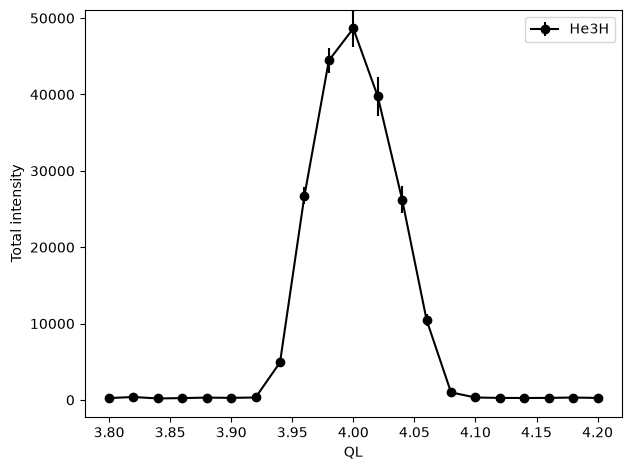

Scan point 1/21 complete: QL = 3.8
Scan point 2/21 complete: QL = 3.82
Scan point 3/21 complete: QL = 3.84
Scan point 4/21 complete: QL = 3.86
Scan point 5/21 complete: QL = 3.88
Scan point 6/21 complete: QL = 3.9
Scan point 7/21 complete: QL = 3.92
Scan point 8/21 complete: QL = 3.94
Scan point 9/21 complete: QL = 3.96
Scan point 10/21 complete: QL = 3.98
Scan point 11/21 complete: QL = 4.0
Scan point 12/21 complete: QL = 4.02
Scan point 13/21 complete: QL = 4.04
Scan point 14/21 complete: QL = 4.0600000000000005
Scan point 15/21 complete: QL = 4.08
Scan point 16/21 complete: QL = 4.1
Scan point 17/21 complete: QL = 4.12
Scan point 18/21 complete: QL = 4.140000000000001
Scan point 19/21 complete: QL = 4.16
Scan point 20/21 complete: QL = 4.18
Scan point 21/21 complete: QL = 4.2


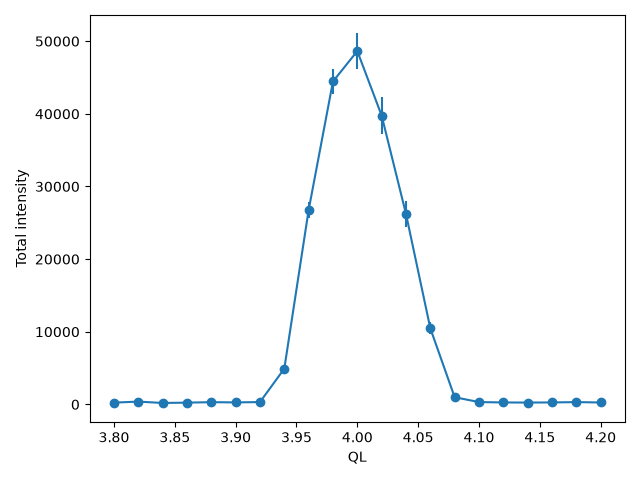

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='QL', ylabel='Total intensity'>)

In [3]:
scan = exercise.scan(
    sim_interface,
    parameter_name="QL",   # change this parameter name to whichever parameter you want to scan over
    start=3.8,             # start ...
    stop=4.2,              # ... and end steps of the scan
    steps=21,              # number of simulation steps to do
    monitor_name="He3H",
    ncount=1e6,            # number of neutron rays to simulate for each scan step
)
scan.plot_monitor("He3H")

### Some other ways to manipulate the scan data
The following cells are Python code examples on how to plot the scan data and calculate things with it.

#### Plot the scan figure with a logarithmic axis instead

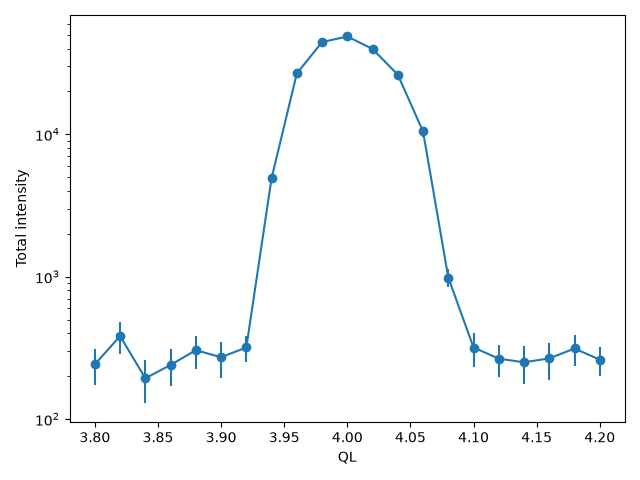

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='QL', ylabel='Total intensity'>)

In [15]:
scan.plot_monitor("He3H", logy=True)

#### Get the peak-to-background ratio

In [16]:
import numpy as np   # numpy gives us array maths (max, argmax, mean, abs)

x, I, err = scan.get_monitor_data("He3H")   # x = QL values, I = intensity per point, err = error bar on I

# Print raw numbers so you can see where the peak and the flat background are
for xi, Ii, ei in zip(x, I, err):   # loop over the three arrays together, one scan point at a time
    print(f"QL = {xi:.3f}   I = {Ii:.4g} +/- {ei:.2g}")   # QL to 3 decimals, intensity to 4 significant digits, error to 2

peak = I.max()            # highest intensity in the whole scan = the Bragg peak height
peak_pos = x[I.argmax()]  # argmax gives the index of that highest point; x[...] looks up its QL value

# Background: average of the points far from the peak (adjust the 0.15 if the peak is even wider)
far = np.abs(x - peak_pos) > 0.15   # True for points more than 0.15 r.l.u. from the peak centre, False otherwise
background = I[far].mean()   # keep only the "far" points (boolean mask) and average them = background level

print(f"\nPeak at QL = {peak_pos:.3f}, intensity = {peak:.4g}")   # report where the peak is and how high
print(f"Background = {background:.4g}")                           # report the average background intensity
print(f"Peak / background = {peak / background:.1f}")             # the answer to the quiz: peak height divided by background

QL = 3.800   I = 242.6 +/- 68
QL = 3.820   I = 382.7 +/- 97
QL = 3.840   I = 193.5 +/- 65
QL = 3.860   I = 240 +/- 70
QL = 3.880   I = 304.6 +/- 81
QL = 3.900   I = 271.9 +/- 78
QL = 3.920   I = 318.3 +/- 67
QL = 3.940   I = 4918 +/- 3.8e+02
QL = 3.960   I = 2.675e+04 +/- 1.1e+03
QL = 3.980   I = 4.446e+04 +/- 1.7e+03
QL = 4.000   I = 4.864e+04 +/- 2.4e+03
QL = 4.020   I = 3.977e+04 +/- 2.6e+03
QL = 4.040   I = 2.622e+04 +/- 1.8e+03
QL = 4.060   I = 1.047e+04 +/- 8.4e+02
QL = 4.080   I = 986.6 +/- 1.4e+02
QL = 4.100   I = 318.1 +/- 86
QL = 4.120   I = 265.8 +/- 68
QL = 4.140   I = 250.5 +/- 74
QL = 4.160   I = 266.8 +/- 78
QL = 4.180   I = 313.1 +/- 75
QL = 4.200   I = 261.4 +/- 59

Peak at QL = 4.000, intensity = 4.864e+04
Background = 276.7
Peak / background = 175.8


## Visualize instrument

In [ ]:
sim_interface.instrument.show_instrument(backend="pythreejs")